# Step 2: Audio-Text Similarity Analysis

In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_DIR = os.path.dirname(os.getcwd())
RESULTS_DIR = os.path.join(PROJECT_DIR, 'results')
CSV_PATH    = os.path.join(PROJECT_DIR, 'data', 'metadata_500.csv')
AUDIO_DIR   = os.path.join(PROJECT_DIR, 'data', 'audio')

# 加载向量
audio_emb = np.load(os.path.join(RESULTS_DIR, 'audio_embeddings.npy'))  # (497, 512)
text_emb  = np.load(os.path.join(RESULTS_DIR, 'text_embeddings.npy'))   # (497, 512)

# 过滤掉坏文件，和 notebook 01 保持一致
import soundfile as sf
df = pd.read_csv(CSV_PATH)
audio_paths = [os.path.join(AUDIO_DIR, row['audio_filename']) for _, row in df.iterrows()]
bad_set = set()
for p in audio_paths:
    try:
        data, _ = sf.read(p)
        if len(data) == 0:
            bad_set.add(p)
    except:
        bad_set.add(p)
clean_df = df[[p not in bad_set for p in audio_paths]].reset_index(drop=True)

print('audio_emb shape:', audio_emb.shape)
print('text_emb shape: ', text_emb.shape)
print('样本数:', len(clean_df))

audio_emb shape: (497, 512)
text_emb shape:  (497, 512)
样本数: 497


In [3]:
# L2 归一化（cosine similarity = 归一化后的点积）
audio_norm = audio_emb / np.linalg.norm(audio_emb, axis=1, keepdims=True)
text_norm  = text_emb  / np.linalg.norm(text_emb,  axis=1, keepdims=True)

# 497x497 相似度矩阵
sim_matrix = audio_norm @ text_norm.T  # (497, 497)

# 对角线 = 配对相似度
paired_sim = np.diag(sim_matrix)

print('相似度矩阵 shape:', sim_matrix.shape)
print(f'配对相似度  均值: {paired_sim.mean():.4f}')
print(f'配对相似度  最高: {paired_sim.max():.4f}')
print(f'配对相似度  最低: {paired_sim.min():.4f}')

相似度矩阵 shape: (497, 497)
配对相似度  均值: 0.3778
配对相似度  最高: 0.7214
配对相似度  最低: -0.0639


In [4]:
# 检索指标：Audio -> Text（给定音频，能否找到对应文字）
def compute_retrieval_metrics(sim_matrix):
    n = sim_matrix.shape[0]
    # 每行按相似度降序排列，看正确答案（对角线）排在第几位
    ranks = []
    for i in range(n):
        row = sim_matrix[i]
        rank = np.sum(row >= row[i]) - 1  # 有多少个比自己高（0-indexed）
        ranks.append(rank)
    ranks = np.array(ranks)
    metrics = {
        'R@1':  float(np.mean(ranks < 1)),
        'R@5':  float(np.mean(ranks < 5)),
        'R@10': float(np.mean(ranks < 10)),
        'MedR': float(np.median(ranks) + 1),
    }
    return metrics

a2t = compute_retrieval_metrics(sim_matrix)    # Audio -> Text
t2a = compute_retrieval_metrics(sim_matrix.T)  # Text -> Audio

print('Audio -> Text:')
for k, v in a2t.items():
    print(f'  {k}: {v:.4f}')
print('Text -> Audio:')
for k, v in t2a.items():
    print(f'  {k}: {v:.4f}')

Audio -> Text:
  R@1: 0.2636
  R@5: 0.6680
  R@10: 0.8028
  MedR: 3.0000
Text -> Audio:
  R@1: 0.2515
  R@5: 0.6861
  R@10: 0.8270
  MedR: 3.0000


/var/folders/tf/5ql6fmn1579_5_q998vk553r0000gp/T/ipykernel_81881/3007299802.py:11: UserWarning: Glyph 36127 (\N{CJK UNIFIED IDEOGRAPH-8D1F}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/tf/5ql6fmn1579_5_q998vk553r0000gp/T/ipykernel_81881/3007299802.py:11: UserWarning: Glyph 20363 (\N{CJK UNIFIED IDEOGRAPH-4F8B}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/tf/5ql6fmn1579_5_q998vk553r0000gp/T/ipykernel_81881/3007299802.py:11: UserWarning: Glyph 65288 (\N{FULLWIDTH LEFT PARENTHESIS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/tf/5ql6fmn1579_5_q998vk553r0000gp/T/ipykernel_81881/3007299802.py:11: UserWarning: Glyph 38750 (\N{CJK UNIFIED IDEOGRAPH-975E}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/tf/5ql6fmn1579_5_q998vk553r0000gp/T/ipykernel_81881/3007299802.py:11: UserWarning: Glyph 37197 (\N{CJK UNIFIED IDEOGRAPH-914D}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/tf/5ql6

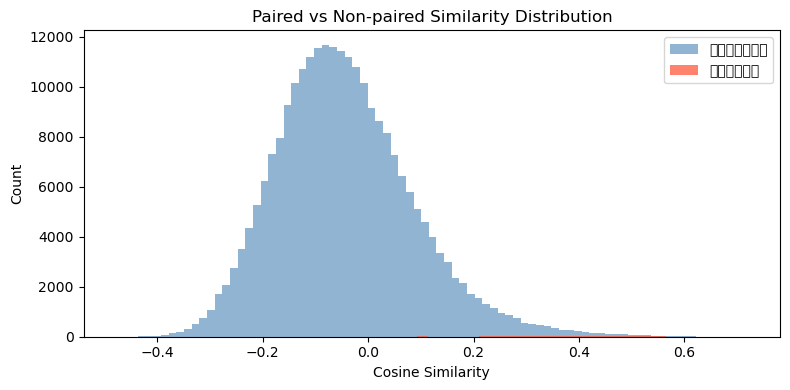

In [5]:
# 可视化1：配对相似度分布（正例 vs 负例）
off_diag = sim_matrix[~np.eye(sim_matrix.shape[0], dtype=bool)]  # 所有非配对相似度

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(off_diag, bins=80, alpha=0.6, label='负例（非配对）', color='steelblue')
ax.hist(paired_sim, bins=40, alpha=0.8, label='正例（配对）', color='tomato')
ax.set_xlabel('Cosine Similarity')
ax.set_ylabel('Count')
ax.set_title('Paired vs Non-paired Similarity Distribution')
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'similarity_distribution.png'), dpi=150)
plt.show()

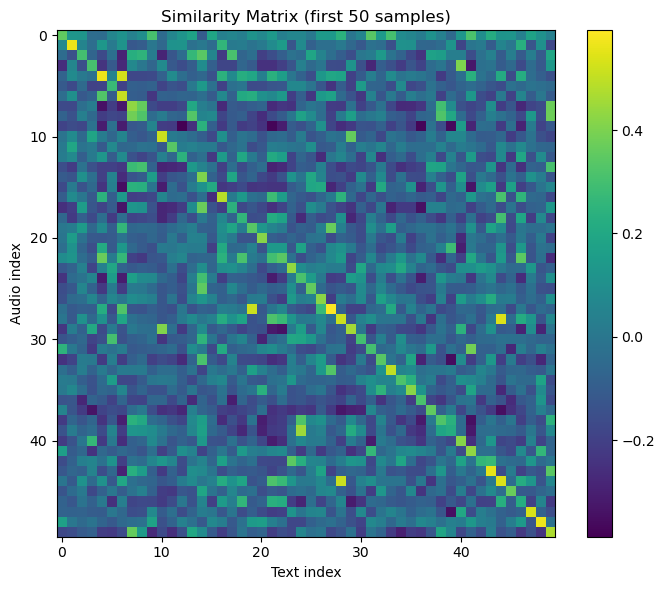

In [6]:
# 可视化2：相似度矩阵热力图（取前50个样本看对角线是否突出）
fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(sim_matrix[:50, :50], cmap='viridis', aspect='auto')
plt.colorbar(im, ax=ax)
ax.set_title('Similarity Matrix (first 50 samples)')
ax.set_xlabel('Text index')
ax.set_ylabel('Audio index')
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'similarity_matrix.png'), dpi=150)
plt.show()

In [7]:
# 找出配对相似度最高和最低的样本
top5_idx = np.argsort(paired_sim)[::-1][:5]
bot5_idx = np.argsort(paired_sim)[:5]

print('相似度最高的5对:')
for i in top5_idx:
    print(f'  [{i}] sim={paired_sim[i]:.4f} | {clean_df.iloc[i]["caption"]}')

print('\n相似度最低的5对:')
for i in bot5_idx:
    print(f'  [{i}] sim={paired_sim[i]:.4f} | {clean_df.iloc[i]["caption"]}')

相似度最高的5对:
  [392] sim=0.7214 | loud, continuous tapping on a typewriter
  [121] sim=0.6831 | two men speaking with loud insects buzzing
  [355] sim=0.6735 | Snoring and then a speech
  [373] sim=0.6681 | food and oil sizzling followed by oil popping then steam hissing as a man talks and light music plays in the background
  [249] sim=0.6489 | wind blowing heavily into a microphone as a speedboat drives by and water splashes in the distance followed by a man talking

相似度最低的5对:
  [187] sim=-0.0639 | music plays as a man is singing followed by muffled rapid gunshots firing
  [59] sim=-0.0516 | music is playing with machine gun sounds
  [421] sim=0.0154 | white noise continues then something begins clicking
  [61] sim=0.0290 | nature sounds with a frog croaking
  [439] sim=0.0303 | gravely sound with womans voice in background


In [8]:
# 保存相似度矩阵和配对相似度
np.save(os.path.join(RESULTS_DIR, 'sim_matrix.npy'),  sim_matrix)
np.save(os.path.join(RESULTS_DIR, 'paired_sim.npy'),  paired_sim)
print('保存完成！')

保存完成！
